In [134]:
pip install sklearn

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 7.4/7.4 MB 15.8 MB/s eta 0:00:00
     ---------------------------------------- 307.0/307.0 kB ? eta 0:00:00
  Created wheel for sklearn: filename=sklearn-0.0-py2.py3-none-any.whl size=1310 sha256=3fb3aad69f3dd86f84986d9a7b3e5a390b9bafcfcd36c9df00229cee995af198
  Stored in directory: c:\users\usuario\appdata\local\pip\cache\wheels\e4\7b\98\b6466d71b8d738a0c547008b9eb39bf8676d1ff6ca4b22af1c
Successfully built sklearn
Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import numpy as np
import matplotlib as mpl

TRAIN_PATH = 'datasets/ISIC_2020_corrected/train'
train_images = os.listdir(TRAIN_PATH)
train_images

['ISIC_0015719.jpg',
 'ISIC_0052212.jpg',
 'ISIC_0068279.jpg',
 'ISIC_0074268.jpg',
 'ISIC_0074311.jpg',
 'ISIC_0074542.jpg',
 'ISIC_0075663.jpg',
 'ISIC_0075914.jpg',
 'ISIC_0076262.jpg',
 'ISIC_0076545.jpg',
 'ISIC_0076742.jpg',
 'ISIC_0076995.jpg',
 'ISIC_0077472.jpg',
 'ISIC_0077735.jpg',
 'ISIC_0078703.jpg',
 'ISIC_0078712.jpg',
 'ISIC_0079038.jpg',
 'ISIC_0080512.jpg',
 'ISIC_0080752.jpg',
 'ISIC_0080817.jpg',
 'ISIC_0081956.jpg',
 'ISIC_0082348.jpg',
 'ISIC_0082543.jpg',
 'ISIC_0082934.jpg',
 'ISIC_0083035.jpg',
 'ISIC_0084086.jpg',
 'ISIC_0084270.jpg',
 'ISIC_0084395.jpg',
 'ISIC_0085172.jpg',
 'ISIC_0085718.jpg',
 'ISIC_0085902.jpg',
 'ISIC_0086349.jpg',
 'ISIC_0086462.jpg',
 'ISIC_0086632.jpg',
 'ISIC_0086709.jpg',
 'ISIC_0087290.jpg',
 'ISIC_0087297.jpg',
 'ISIC_0088137.jpg',
 'ISIC_0088489.jpg',
 'ISIC_0089401.jpg',
 'ISIC_0089569.jpg',
 'ISIC_0089738.jpg',
 'ISIC_0090279.jpg',
 'ISIC_0091016.jpg',
 'ISIC_0091559.jpg',
 'ISIC_0091996.jpg',
 'ISIC_0092726.jpg',
 'ISIC_009287

In [3]:
import pandas as pd

train_csv = pd.read_csv(f'datasets/ISIC_2020_corrected/train.csv')
train_csv.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0


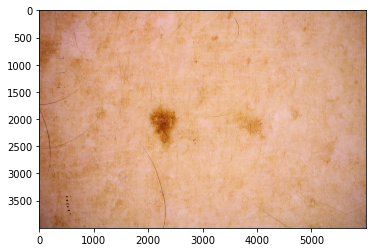

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(f'datasets/ISIC_2020_corrected/train/{train_images[0]}')
plt.imshow(img)

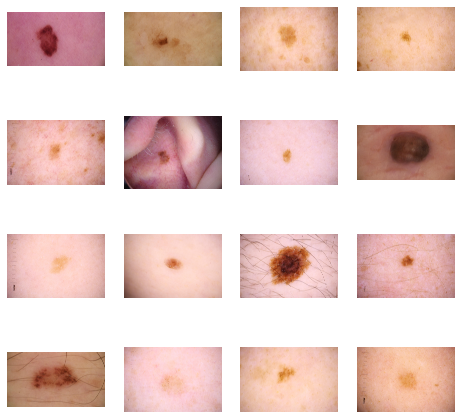

In [7]:
import random

r,c = 4, 4

fig = plt.figure(figsize=(2*c, 2*r))
for _r in range(r):
    for _c in range(c):
        plt.subplot(r, c, _r*c + _c + 1)
        ix = random.randint(0, len(train_images)-1)
        img = Image.open(f'{TRAIN_PATH}/{train_images[ix]}')
        plt.imshow(img)
        plt.axis(False)

In [9]:
train_csv = pd.read_csv(f'datasets/ISIC_2020_corrected/train.csv')
train_csv.shape


(33126, 9)

<AxesSubplot:>

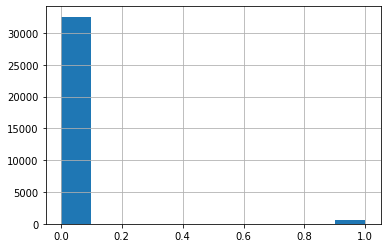

In [10]:
train_csv["target"].hist()

(array([2.7124e+04, 5.1930e+03, 5.8400e+02, 1.3500e+02, 0.0000e+00,
        4.4000e+01, 3.7000e+01, 7.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([0. , 0.8, 1.6, 2.4, 3.2, 4. , 4.8, 5.6, 6.4, 7.2, 8. ]),
 <BarContainer object of 10 artists>)

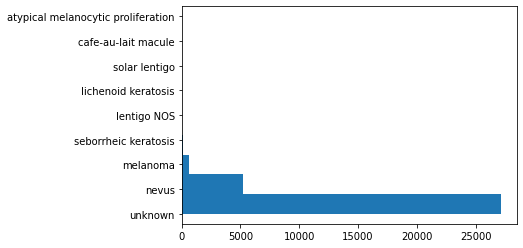

In [24]:
plt.hist(train_csv["diagnosis"], orientation='horizontal')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


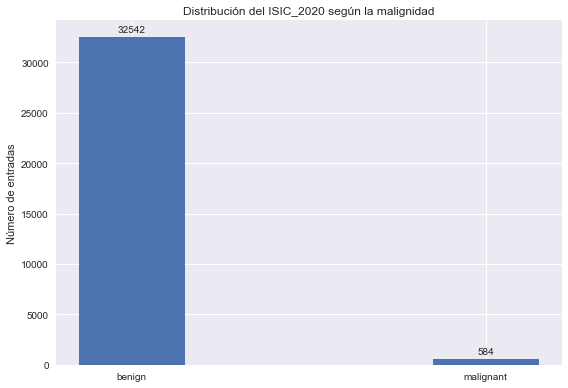

In [17]:

a = train_csv["benign_malignant"].value_counts()
l = []
for i in a.keys():
    l.append((str(i), a[i]))
l.sort()
y_values = []
labels = []
x = range(len(l))
for i in l:
    y_values.append(i[1])
    labels.append(i[0])
x = np.arange(len(labels))  # the label locations
width = 0.3  # the width of the bars

mpl.style.use('seaborn')
fig, ax = plt.subplots()
rects1 = ax.bar(x, y_values, width)
ax.set_ylabel('Número de entradas')
ax.set_title('Distribución del ISIC_2020 según la malignidad')
ax.set_xticks(x, labels)
ax.legend()

ax.bar_label(rects1, padding=3)
fig.tight_layout()
plt.savefig('distribucion_malignidad', dpi=100)
plt.show()

In [23]:
train_csv["diagnosis"].value_counts()

unknown                               27124
nevus                                  5193
melanoma                                584
seborrheic keratosis                    135
lentigo NOS                              44
lichenoid keratosis                      37
solar lentigo                             7
cafe-au-lait macule                       1
atypical melanocytic proliferation        1
Name: diagnosis, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(train_csv, test_size=0.3, shuffle=True, random_state=42, stratify=train_csv['target'])
train_split.shape, val_split.shape

((23188, 9), (9938, 9))

In [13]:
_, subset = train_test_split(train_split, test_size=0.1, shuffle=True, random_state=42, stratify=train_split['target'])
subset.shape

(2319, 9)

In [14]:
val_split, test_split = train_test_split(val_split, test_size=0.5, shuffle=True, random_state=42, stratify=val_split['target'])
val_split.shape, test_split.shape

((4969, 9), (4969, 9))

In [18]:
train_sd_split = train_csv[~train_csv.apply(tuple, 1).isin(test_split.apply(tuple, 1))]
train_sd_split.shape

(28157, 9)

In [20]:
train_split.to_csv('datasets/ISIC_2020_corrected/train_split.csv', index=False)
val_split.to_csv('datasets/ISIC_2020_corrected/val_split.csv', index=False)
subset.to_csv('datasets/ISIC_2020_corrected/subset.csv', index=False)
test_split.to_csv('datasets/ISIC_2020_corrected/test_split.csv', index=False)
train_sd_split.to_csv('datasets/ISIC_2020_corrected/train_sd_split.csv', index=False)